## Setup

In [1]:
import sys
sys.path.insert(0, "../../src/python/")

In [2]:
import os
import pickle
import random
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Configuration

In [3]:
# TRAIN_IMAGE_DIR = "/mnt/d/skin-lesion-data/final-data/train/"
# TRAIN_LABEL_FILE = "/mnt/d/skin-lesion-data/final-data/labels/mappings.pkl"

# VAL_IMAGE_DIR = "/mnt/d/skin-lesion-data/final-data/test"
# VAL_LABEL_FILE = "/mnt/d/skin-lesion-data/final-data/test_labels/mappings_test.pkl"

TRAIN_IMAGE_DIR = "/home/shadeform/data/train/"
TRAIN_LABEL_FILE = "/home/shadeform/data/labels/mappings.pkl"

VAL_IMAGE_DIR = "/home/shadeform/data/test/"
VAL_LABEL_FILE = "/home/shadeform/data/labels/mappings_test.pkl"

In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

EPOCHS_HEAD = 5
EPOCHS_FINETUNE = 20

HEAD_LR = 3e-4
BACKBONE_LR = 1e-5

NUM_CLASSES = 8

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

## Dataset Class

In [5]:
CLASS_TO_IDX = {"MEL": 0, "NV": 1, "BCC": 2, "AK": 3, "BKL": 4, "DF": 5, "VASC": 6, "SCC": 7}

class SkinLesionDataset(Dataset):

    def __init__(self, image_dir, label_file, transform=None):

        self.image_dir = image_dir
        self.transform = transform

        with open(label_file, "rb") as f:
            self.labels = pickle.load(f)

        self.image_names = list(self.labels.keys())

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):

        image_name = self.image_names[idx]
        if "." not in image_name:
            image_name += ".jpg"
        image_path = os.path.join(self.image_dir, image_name)
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.labels[self.image_names[idx]]
        if isinstance(label, str):
            label = CLASS_TO_IDX[label]
        return image, label

## Transforms

In [6]:
train_transform = transforms.Compose([transforms.RandomResizedCrop(224, scale=(0.8,1.0)), transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
                                      transforms.RandomRotation(20), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                                      transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])])

val_transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])])

## Dataset and DataLoader

In [7]:
import random
from torch.utils.data import DataLoader

random.seed(42)
TARGET_COUNTS = {"MEL": 5000, "NV": 5000, "BCC": 3316, "AK": 1056, "BKL": 2829, "DF": 239, "VASC": 253, "SCC": 431}

train_dataset = SkinLesionDataset(TRAIN_IMAGE_DIR, TRAIN_LABEL_FILE, train_transform)
val_dataset = SkinLesionDataset(VAL_IMAGE_DIR, VAL_LABEL_FILE, val_transform)

class_to_images = {}

for img_name in train_dataset.image_names:
    label = train_dataset.labels[img_name]

    if label not in class_to_images:
        class_to_images[label] = []

    class_to_images[label].append(img_name)

balanced_images = []
for label, images in class_to_images.items():
    target = TARGET_COUNTS.get(label, len(images))
    if len(images) > target:
        balanced_images.extend(random.sample(images, target))
    else:
        balanced_images.extend(images)

random.shuffle(balanced_images)
train_dataset.image_names = balanced_images

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=16, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=16, pin_memory=True)

print("\nBalanced Training Distribution\n")

for cls in ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"]:
    print(f"{cls:<5}: {TARGET_COUNTS[cls]}")

print()

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(val_dataset)}")
print(f"Batch Size        : 32")
print(f"Workers           : 16")
print(f"Weighted Sampler  : False")
print(f"Downsampling      : True")


Balanced Training Distribution

MEL  : 5000
NV   : 5000
BCC  : 3316
AK   : 1056
BKL  : 2829
DF   : 239
VASC : 253
SCC  : 431

Training Images   : 18124
Validation Images : 8238
Batch Size        : 32
Workers           : 16
Weighted Sampler  : False
Downsampling      : True


/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


## Model

In [8]:
weights = EfficientNet_B3_Weights.DEFAULT
model = efficientnet_b3(weights=weights)
model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(model.classifier[1].in_features, NUM_CLASSES))
model = model.to(DEVICE)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.classifier[1].in_features, NUM_CLASSES))
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /home/shadeform/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47.2M/47.2M [00:00<00:00, 219MB/s]


## Loss, Optimizer & Scheduler

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=HEAD_LR, weight_decay=1e-4)

## Training

In [10]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    preds = []
    labels = []

    for images, target in tqdm(loader):

        images = images.to(DEVICE)
        target = target.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pred = outputs.argmax(1)
        preds.extend(pred.cpu().numpy())
        labels.extend(target.cpu().numpy())

    acc = accuracy_score(labels, preds)

    return running_loss/len(loader), acc

## Validation Function

In [11]:
def validate(model, loader):

    model.eval()

    running_loss = 0
    preds = []
    labels = []

    with torch.no_grad():

        for images, target in tqdm(loader):

            images = images.to(DEVICE)
            target = target.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, target)
            running_loss += loss.item()
            pred = outputs.argmax(1)
            preds.extend(pred.cpu().numpy())
            labels.extend(target.cpu().numpy())

    acc = accuracy_score(labels, preds)
    return (running_loss/len(loader), acc, labels, preds)

## Training Loop

In [12]:
best_acc = 0

for epoch in range(EPOCHS_HEAD):

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, _, _ = validate(model, val_loader)
    print(epoch+1, train_acc, val_acc)
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

  0%|                                                                                                                                                                                  | 0/258 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 258/258 [00:10<00:00, 24.73it/s]


1 0.4515559479143677 0.42923039572711824


  0%|                                                                                                                                                                                  | 0/567 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
  0%|                                                                                                                                                                                  | 0/258 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10

2 0.511366144338998 0.44258315125030345


  0%|                                                                                                                                                                                  | 0/567 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
  0%|                                                                                                                                                                                  | 0/258 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10

3 0.5196424630324432 0.4453750910415149


  0%|                                                                                                                                                                                  | 0/567 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
  0%|                                                                                                                                                                                  | 0/258 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10

4 0.5208011476495255 0.4395484340859432


  0%|                                                                                                                                                                                  | 0/567 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
  0%|                                                                                                                                                                                  | 0/258 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10

5 0.5283601853895388 0.44440398154891964


## Fine Tuning Optimizer

In [13]:
optimizer = torch.optim.AdamW([
        {"params": model.features.parameters(), "lr": BACKBONE_LR},
        {"params": model.classifier.parameters(), "lr": HEAD_LR/10}], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FINETUNE)

In [14]:
patience = 5
counter = 0

for epoch in range(EPOCHS_FINETUNE):

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, _, _ = validate(model, val_loader)

    scheduler.step()
    print(epoch+1, train_acc, val_acc)
    if val_acc > best_acc:
        best_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

  0%|                                                                                                                                                                                  | 0/567 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
  0%|                                                                                                                                                                                  | 0/258 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10

1 0.5297947472964025 0.44234037387715464


  0%|                                                                                                                                                                                  | 0/567 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
  0%|                                                                                                                                                                                  | 0/258 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10

2 0.5307327300816597 0.4422189851905802


  0%|                                                                                                                                                                                  | 0/567 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
  0%|                                                                                                                                                                                  | 0/258 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10

...

12 0.5329397483999118 0.4484098082058752


  0%|                                                                                                                                                                                  | 0/567 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
  0%|                                                                                                                                                                                  | 0/258 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10

13 0.5384021187375855 0.4558145180869143


  0%|                                                                                                                                                                                  | 0/567 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
  0%|                                                                                                                                                                                  | 0/258 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10

14 0.5354778194659016 0.4376062151007526
Early stopping


## Load Best Model

In [15]:
model.load_state_dict(torch.load("efficientnet_b0_best.pth", map_location=DEVICE))
model.eval()

/tmp/ipykernel_21915/3902170796.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("efficientnet_b0_best.pth", map_location=DEVICE))


RuntimeError: Error(s) in loading state_dict for EfficientNet:
	Missing key(s) in state_dict: "features.1.1.block.0.0.weight", "features.1.1.block.0.1.weight", "features.1.1.block.0.1.bias", "features.1.1.block.0.1.running_mean", "features.1.1.block.0.1.running_var", "features.1.1.block.1.fc1.weight", "features.1.1.block.1.fc1.bias", "features.1.1.block.1.fc2.weight", "features.1.1.block.1.fc2.bias", "features.1.1.block.2.0.weight", "features.1.1.block.2.1.weight", "features.1.1.block.2.1.bias", "features.1.1.block.2.1.running_mean", "features.1.1.block.2.1.running_var", "features.2.2.block.0.0.weight", "features.2.2.block.0.1.weight", "features.2.2.block.0.1.bias", "features.2.2.block.0.1.running_mean", "features.2.2.block.0.1.running_var", "features.2.2.block.1.0.weight", "features.2.2.block.1.1.weight", "features.2.2.block.1.1.bias", "features.2.2.block.1.1.running_mean", "features.2.2.block.1.1.running_var", "features.2.2.block.2.fc1.weight", "features.2.2.block.2.fc1.bias", "featu

## Evaluation

In [16]:
_, _, y_true, y_pred = validate(model, val_loader)

print(classification_report(y_true, y_pred))

  0%|                                                                                                                                                                                  | 0/258 [00:00<?, ?it/s]/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 258/258 [00:10<00:00, 24.76it/s]

              precision    recall  f1-score   support

           0       0.54      0.34      0.42      3374
           1       0.81      0.55      0.65      2495
           2       0.24      0.77      0.37       975
           3       0.20      0.19      0.19       374
           4       0.26      0.33      0.29       660
           5       0.15      0.02      0.04        91
           6       0.13      0.10      0.11       104
           7       0.14      0.06      0.08       165

    accuracy                           0.43      8238
   macro avg       0.31      0.29      0.27      8238
weighted avg       0.53      0.43      0.45      8238



## Confusion Matrix

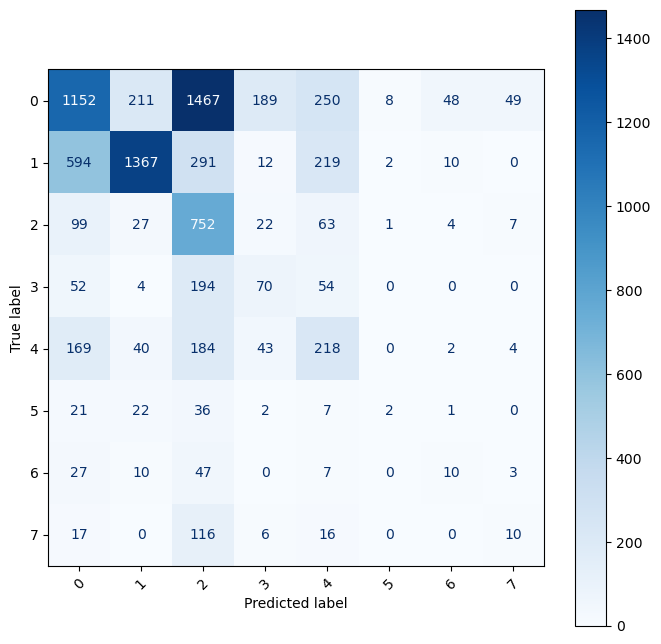

In [17]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.show()

In [ ]:
import os

print(os.listdir(VAL_IMAGE_DIR)[:10])